# Dark Pattern Detector — Notebook 3: Deep Learning Comparison

This notebook is self-contained. Its classical baseline repeats the exact Notebook 2 grouping
and model definition, then compares it with an LSTM and an optional DistilBERT fine-tune.

## 0. Colab setup (skip locally)

On Colab this clones the project and installs only the transformer package used later.

In [1]:
import os, sys

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    repo = "/content/dark-pattern-detector"
    if not os.path.isdir(repo):
        os.system(f"git clone https://github.com/goyashek/dark-pattern-detector.git {repo}")
    os.chdir(repo)
    os.system("pip -q install transformers")

from pathlib import Path
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
print("Project root:", ROOT)

Project root: /Users/abhigoyal/Documents/Acadss/Data Science/Projects/dark-pattern-final


## 1. Import Libraries

In [2]:
import hashlib, json, re
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, PowerTransformer, RobustScaler
from sklearn.svm import LinearSVC

SEED = 42
np.random.seed(SEED)
results = {}

In [3]:
MODEL_NUM_COLS = ['urgency_kw_count', 'scarcity_kw_count', 'shame_phrase_flag', 'cancel_diff_score', 'social_proof_flag', 'price_drip_flag', 'discount_claim_flag', 'neg_option_flag', 'exclamation_count', 'question_count', 'number_present', 'time_reference_flag']
SLOT_VALUES = ['Tata CLiQ', 'Flipkart', 'Meesho', 'IndiaMART', 'Snapdeal', 'AJIO', 'Amazon Prime Video', 'Fitbit', 'Google Drive', 'Hostinger', 'Reliance Smart Bazaar', 'Amazon', 'Myntra', 'Croma', 'MakeMyTrip', 'BigBasket', 'JioGames', 'Paytm Money', 'sneakers', 'headphones', 'smartwatch', 'backpack', 'jacket', 'blender', 'office chair', 'yoga mat', 'coffee maker', 'desk lamp', 'phone case', 'sunglasses', 'water bottle', 'bluetooth speaker', 'air fryer', 'wallet', 'service charge', 'processing fee', 'convenience fee', 'admin surcharge', 'handling fee', 'cleanup cost', 'booking charge', 'platform fee', 'payment gateway fee', 'fulfilment fee', 'packaging fee', 'Protect Promise Fee', 'Offer Handling Fee', 'Payment Handling Fee', 'small cart charge', 'handling charge', 'delivery charge', 'pick up charge', 'surge fee', 'rain fee', 'high demand fee', 'Quick Heal', 'K7 Total Security', 'TallyPrime', 'Busy Accounting', 'Zoho Books', 'Microsoft 365', 'GST Invoice', 'Bank Statement', 'Aadhaar Copy', 'PAN Card Copy', 'Insurance Policy', 'Salary Slip', 'shipping protection', 'priority handling', 'extended warranty', 'loss protection', 'theft insurance', 'carbon offset', 'gift wrapping', 'express processing', 'damage cover', 'installation support', 'E-commerce', 'Fintech', 'Travel', 'Food Delivery', 'Streaming', 'Telecom', 'Healthcare', 'Education', '7 days', '15 days', '1 month', '3 months', '6 months', '1 year']

_VOCAB_RE = re.compile("|".join(map(re.escape, sorted(SLOT_VALUES, key=len, reverse=True))), re.I)
_CUR_RE = re.compile(r"[₹$]\s?\d[\d,]*(?:\.\d+)?")
_PCT_RE = re.compile(r"\d+\s?%")
_NUM_RE = re.compile(r"\d[\d,]*(?:\.\d+)?")

def skeleton(text):
    text = _CUR_RE.sub("<CUR>", str(text))
    text = _PCT_RE.sub("<PCT>", text)
    text = _VOCAB_RE.sub("<SLOT>", text)
    text = _NUM_RE.sub("<NUM>", text)
    return re.sub(r"\s+", " ", text).strip().lower()

def connected_groups(frame):
    parent = list(range(len(frame)))

    def find(i):
        while parent[i] != i:
            parent[i] = parent[parent[i]]
            i = parent[i]
        return i

    def union(a, b):
        a, b = find(a), find(b)
        if a != b:
            parent[b] = a

    for values in (frame["page_id"], frame["text"].fillna("").map(skeleton)):
        seen = {}
        for i, value in enumerate(values):
            if pd.isna(value) or not str(value).strip():
                continue
            key = str(value)
            union(i, seen[key]) if key in seen else seen.setdefault(key, i)

    return pd.factorize(np.asarray([find(i) for i in range(len(frame))]))[0]

def dataset_hash(frame):
    cols = ["page_id", "text", "label", "Pattern Category"]
    return hashlib.sha256(frame[cols].to_csv(index=False, lineterminator="\n").encode()).hexdigest()

def load_split(frame, path):
    split = json.loads(Path(path).read_text())
    train, test = np.array(split["train"]), np.array(split["test"])
    assert not set(train) & set(test)
    assert set(train) | set(test) == set(range(len(frame)))
    assert split["dataset_sha256"] == dataset_hash(frame), "stale split; rebuild it before training"
    groups = connected_groups(frame)
    assert not set(groups[train]) & set(groups[test]), "page/template leakage remains"
    return split, train, test, groups

def make_model(c=0.5):
    prep = ColumnTransformer([
        ("text", TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 6), min_df=2,
                                 max_features=30_000, sublinear_tf=True), "text"),
        ("numeric", Pipeline([
            ("scale", RobustScaler()),
            ("power", PowerTransformer(method="yeo-johnson")),
        ]), MODEL_NUM_COLS),
    ])
    return ImbPipeline([
        ("prep", prep),
        ("smote", SMOTE(random_state=42)),
        ("clf", LinearSVC(C=c, random_state=42, max_iter=2_000, tol=1e-3)),
    ])

def grouped_folds(x, y, groups, n_splits=5):
    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
    folds = list(cv.split(x, y, groups))
    classes = set(y)
    assert all(set(y[a]) == classes == set(y[b]) for a, b in folds), "a fold is missing a class"
    return folds

def calibrated_model(model, folds):
    return CalibratedClassifierCV(model, method="sigmoid", cv=folds, ensemble=False)

assert len(MODEL_NUM_COLS) == 12

## 2. Load Features and the Source-Aware Split

The split now keeps rows together when they share either a source page or generated template.
Every current evaluation must use these indices.

In [4]:
df = pd.read_csv(ROOT / "data/processed/features.csv").fillna({"text": ""})
split, train_idx, test_idx, groups = load_split(df, ROOT / "reports/leak_free_split.json")
print("rows:", len(df), "| train:", len(train_idx), "| test:", len(test_idx))
print("grouping:", split["grouping"])
df["Pattern Category"].value_counts()

rows: 6373 | train: 5051 | test: 1322
grouping: connected_page_or_skeleton_v1


Pattern Category
Not a Dark Pattern         1855
False Urgency               493
Disguised Advertisement     476
Interface Interference      383
Subscription Trap           345
Basket Sneaking             326
Drip Pricing                326
Forced Action               324
Nagging                     320
Bait and Switch             320
SaaS Billing                320
Rogue Malware               320
Confirm Shaming             315
Trick Question              250
Name: count, dtype: int64

## 3. The Leak Audit in One Picture

Quick recap of *why* we switched splits, straight from `reports/leak_audit.json`. The naive
split's score is inflated because near-duplicate siblings leak across it; the honest split
removes that. Same tuned pipeline from NB2, two different splits.

naive split: 826/1275 test rows (64.8%) had a template twin in train
source-aware split: 0 leaked rows


,naive (optimistic),source-aware
Legacy SVC,0.947,0.515
Legacy XGBoost,0.963,0.657


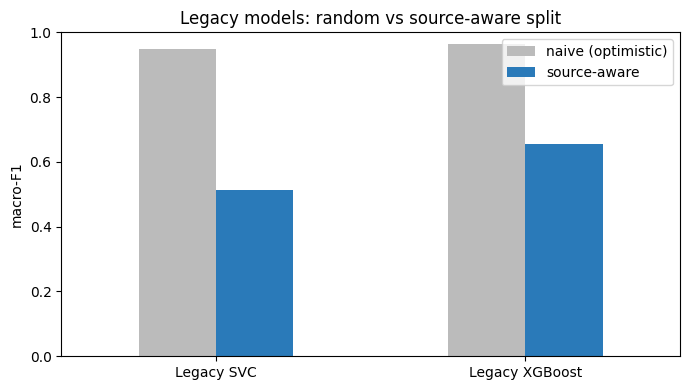

In [5]:
with open(ROOT / 'reports/leak_audit.json') as f:
    audit = json.load(f)

naive = audit['naive_split']
mdl = audit['models']
print(f"naive split: {naive['leaked_test_rows']}/{naive['test_size']} test rows "
      f"({naive['leaked_test_pct']}%) had a template twin in train")
print(f"source-aware split: {audit['leak_free_split']['leaked_test_rows']} leaked rows")

inflation = pd.DataFrame({
    'naive (optimistic)': {k: v['macro_f1_naive'] for k, v in mdl.items()},
    'source-aware': {k: v['macro_f1_leakfree'] for k, v in mdl.items()},
}).rename(index={'legacy_svc': 'Legacy SVC', 'legacy_xgb': 'Legacy XGBoost'})
display(inflation.round(3))

ax = inflation.plot(kind='bar', figsize=(7, 4), color=['#bbb', '#2a7ab9'], rot=0)
ax.set_ylabel('macro-F1'); ax.set_title('Legacy models: random vs source-aware split')
ax.set_ylim(0, 1); plt.tight_layout(); plt.show()

## 4. Targets, Columns and a Shared Scoreboard

We encode the 14 category names to integers once and reuse the encoder everywhere so the
LSTM, DistilBERT and the classical model all speak the same label ids. `evaluate()` is the
single scoring function every model gets graded by — macro-F1 first, because the classes are
imbalanced and we care about the rare ones.

In [6]:
le = LabelEncoder()
y_all = le.fit_transform(df['Pattern Category'])
CLASSES = list(le.classes_)
n_classes = len(CLASSES)

text_train = df['text'].iloc[train_idx].tolist()
text_test = df['text'].iloc[test_idx].tolist()
y_train, y_test = y_all[train_idx], y_all[test_idx]

def evaluate(name, y_true, y_pred, store=True):
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    if store:
        results.setdefault(name, {})['macro_f1'] = round(float(f1), 4)
        results[name]['accuracy'] = round(float(acc), 4)
    print(f"{name:32s} macro-F1={f1:.4f}  accuracy={acc:.4f}")
    return f1, acc

## 5. Current Classical Model

This is the exact Streamlit model family: character 2–6 gram TF-IDF + 12 engineered features
→ SMOTE → LinearSVC (`C=0.5`) → three-fold grouped sigmoid calibration. This cell fits only on
the training partition for honest test predictions; `models/best_multi_model.joblib` is the
separate all-data deployment refit.

In [7]:
CLASSICAL_NAME = 'Classical (12 features + SMOTE)'
X_full = df[['text'] + MODEL_NUM_COLS]
X_train_c, X_test_c = X_full.iloc[train_idx], X_full.iloc[test_idx]
calibration_folds = grouped_folds(
    X_train_c, y_train, groups[train_idx], n_splits=3,
)
classical_model = calibrated_model(make_model(c=0.5), calibration_folds)
classical_model.fit(X_train_c, y_train)
classical_pred = classical_model.predict(X_test_c)
classical_pipes = {CLASSICAL_NAME: classical_model}
evaluate(CLASSICAL_NAME, y_test, classical_pred)

Classical (12 features + SMOTE)  macro-F1=0.7303  accuracy=0.8162


## 6. A From-Scratch LSTM

Now the experiment we *expect* to underperform, documented honestly. The idea: skip the
hand-built features entirely and let a small recurrent net learn from the raw word sequence.
We build our own vocabulary, turn each row into a sequence of token ids, pad to a fixed
length, and train an embedding → LSTM → linear classifier.

Why we expect it to struggle: our rows are short and our dataset is small (~3k rows). LSTMs
trained from scratch are data-hungry and have no outside knowledge of language — every word
meaning has to be learned from these few examples. We give it `class_weight` to fight the
imbalance, but this is the honest "we tried it, here's why it lost" rung of the ladder.

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from collections import Counter

torch.manual_seed(SEED)
device = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

def tokenize(t):
    import re
    return re.findall(r"[a-z0-9₹$%]+|[!?]", str(t).lower())

# vocab from TRAIN ONLY (test words map to <unk> — no peeking)
counter = Counter(tok for t in text_train for tok in tokenize(t))
itos = ['<pad>', '<unk>'] + [w for w, c in counter.items() if c >= 2]
stoi = {w: i for i, w in enumerate(itos)}
MAXLEN = 40

def encode(texts):
    seqs = []
    for t in texts:
        ids = [stoi.get(tok, 1) for tok in tokenize(t)][:MAXLEN]
        ids += [0] * (MAXLEN - len(ids))
        seqs.append(ids)
    return torch.tensor(seqs, dtype=torch.long)

Xtr, Xte = encode(text_train), encode(text_test)
ytr_t = torch.tensor(y_train, dtype=torch.long)
print('vocab size:', len(itos))

device: mps
vocab size: 1725


In [9]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab, emb=64, hid=64, n_cls=14):
        super().__init__()
        self.emb = nn.Embedding(vocab, emb, padding_idx=0)
        self.lstm = nn.LSTM(emb, hid, batch_first=True, bidirectional=True)
        self.drop = nn.Dropout(0.3)
        self.fc = nn.Linear(hid * 2, n_cls)
    def forward(self, x):
        e = self.emb(x)
        out, _ = self.lstm(e)
        pooled = out.max(dim=1).values          # max-pool over time
        return self.fc(self.drop(pooled))

# class weights to counter imbalance (same spirit as class_weight='balanced')
counts = np.bincount(y_train, minlength=n_classes)
weights = torch.tensor(counts.sum() / (n_classes * np.maximum(counts, 1)), dtype=torch.float32).to(device)

model = LSTMClassifier(len(itos), n_cls=n_classes).to(device)
opt = torch.optim.Adam(model.parameters(), lr=2e-3)
loss_fn = nn.CrossEntropyLoss(weight=weights)
loader = DataLoader(TensorDataset(Xtr, ytr_t), batch_size=32, shuffle=True)

EPOCHS = 12
for ep in range(1, EPOCHS + 1):
    model.train(); tot = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward(); opt.step()
        tot += loss.item() * len(xb)
    if ep % 3 == 0 or ep == 1:
        print(f"epoch {ep:2d}  train loss {tot/len(Xtr):.4f}")

model.eval()
with torch.no_grad():
    lstm_pred = model(Xte.to(device)).argmax(1).cpu().numpy()
evaluate('LSTM (from scratch)', y_test, lstm_pred)

epoch  1  train loss 1.5558
epoch  3  train loss 0.1637
epoch  6  train loss 0.0553
epoch  9  train loss 0.0346
epoch 12  train loss 0.0163
LSTM (from scratch)              macro-F1=0.6572  accuracy=0.7844


(0.6572015088301679, 0.7844175491679274)

## 7. Fine-Tuned DistilBERT (the headline model)

DistilBERT already knows English — it was pre-trained on a huge corpus, so it starts with a
real understanding of phrasing instead of learning words from our 3k rows. We **fine-tune**
it (not freeze it): a classification head on top, and we let the whole model's weights adjust
to our 14 classes. This is the step that should finally beat the classical baseline, because
the win comes from understanding *wording* ("cancel anytime*" vs "to cancel, call our
hotline"), which is exactly what bag-of-ngrams misses.

> The latest saved run used `RUN_BERT = True`. Set it to `False` for a quick classical/LSTM-only rerun.

In [10]:
RUN_BERT = True   # <-- flip to True to fine-tune (slow on CPU/MPS)

if RUN_BERT:
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    from torch.utils.data import DataLoader, TensorDataset

    CKPT = 'distilbert-base-uncased'
    tok = AutoTokenizer.from_pretrained(CKPT)

    def bert_encode(texts):
        enc = tok(list(texts), truncation=True, padding='max_length', max_length=64, return_tensors='pt')
        return enc['input_ids'], enc['attention_mask']

    tr_ids, tr_mask = bert_encode(text_train)
    te_ids, te_mask = bert_encode(text_test)
    bert = AutoModelForSequenceClassification.from_pretrained(CKPT, num_labels=n_classes).to(device)

    # Regularised against memorisation: by epoch 4 the train loss hit ~0.03 (the model was
    # just memorising), which hurts generalisation to real OOD text. So we stop at 3 epochs
    # and lean on weight decay to keep the weights from over-specialising to our rows.
    opt_b = torch.optim.AdamW(bert.parameters(), lr=3e-5, weight_decay=0.1)
    loss_b = nn.CrossEntropyLoss(weight=weights)
    dl = DataLoader(TensorDataset(tr_ids, tr_mask, ytr_t), batch_size=16, shuffle=True)

    BERT_EPOCHS = 3
    for ep in range(1, BERT_EPOCHS + 1):
        bert.train(); tot = 0
        for ids, mask, yb in dl:
            ids, mask, yb = ids.to(device), mask.to(device), yb.to(device)
            opt_b.zero_grad()
            out = bert(input_ids=ids, attention_mask=mask).logits
            l = loss_b(out, yb); l.backward(); opt_b.step()
            tot += l.item() * len(ids)
        print(f"epoch {ep}  train loss {tot/len(tr_ids):.4f}")

    bert.eval()
    with torch.no_grad():
        bert_pred = bert(input_ids=te_ids.to(device),
                         attention_mask=te_mask.to(device)).logits.argmax(1).cpu().numpy()
    evaluate('DistilBERT', y_test, bert_pred)

    # stash for OOD + saving later
    globals()['bert'], globals()['tok'], globals()['bert_pred'] = bert, tok, bert_pred
else:
    print("DistilBERT cell is gated (RUN_BERT=False). Flip it to True to fine-tune.")

epoch 1  train loss 0.8299
epoch 2  train loss 0.0983
epoch 3  train loss 0.0392
DistilBERT                       macro-F1=0.8832  accuracy=0.9107


## 8. OOD Development Set

These 28 Indian UI strings cover 9 classes, contain no benign rows, and have influenced model
development. Some OOD entries are from CCPA orders. They remain diagnostics, not an independent
final test. The scores below use the saved classical and DistilBERT artifacts, so no training rerun
is needed.

In [11]:
ood = pd.read_csv(ROOT / 'data/processed/ood_features.csv')
ood = ood[ood['Pattern Category'].isin(CLASSES)].reset_index(drop=True)
print('OOD rows:', len(ood), '| classes covered:', ood['Pattern Category'].nunique())

ood_X = ood[['text'] + MODEL_NUM_COLS]
y_ood = le.transform(ood['Pattern Category'])

OOD rows: 28 | classes covered: 9


In [12]:
# Cheap OOD refresh from the two saved deployment artifacts; no training rerun.
import joblib
from transformers import AutoModelForSequenceClassification, AutoTokenizer

saved_encoder = joblib.load(ROOT / 'models/label_encoder.joblib')
deployed_classical = joblib.load(ROOT / 'models/best_multi_model.joblib')
assert list(saved_encoder.classes_) == CLASSES
ood_classical = deployed_classical.predict(ood_X)
f1, acc = evaluate(CLASSICAL_NAME, y_ood, ood_classical, store=False)
results.setdefault(CLASSICAL_NAME, {})['ood_macro_f1'] = round(float(f1), 4)
results[CLASSICAL_NAME]['ood_accuracy'] = round(float(acc), 4)

# Use the saved deployment artifact locally or from Hugging Face on a clean clone.
bert_dir = ROOT / 'models/distilbert_darkpattern'
bert_source = bert_dir if bert_dir.exists() else 'goyashek/distilbert-darkpattern'
bert_revision = None if bert_dir.exists() else 'fabf3cbeafe43b1c4f99611c98306c4b750cc13c'
ood_tok = AutoTokenizer.from_pretrained(bert_source, revision=bert_revision)
ood_bert_model = AutoModelForSequenceClassification.from_pretrained(bert_source, revision=bert_revision)
bert_meta_path = bert_dir / 'label_map.json'
bert_meta = json.loads(bert_meta_path.read_text()) if bert_meta_path.exists() else {'classes': CLASSES, 'max_length': 64}
assert bert_meta['classes'] == CLASSES
ood_bert_model.to(device).eval()
ii = ood_tok(ood['text'].tolist(), truncation=True, padding=True,
             max_length=bert_meta.get('max_length', 64), return_tensors='pt')
with torch.inference_mode():
    ood_logits = ood_bert_model(**{k: v.to(device) for k, v in ii.items()}).logits
    ood_probs = torch.softmax(ood_logits, dim=1).cpu().numpy()
ood_bert = ood_probs.argmax(1)
f1, acc = evaluate('DistilBERT', y_ood, ood_bert, store=False)
results.setdefault('DistilBERT', {})['ood_macro_f1'] = round(float(f1), 4)
results['DistilBERT']['ood_accuracy'] = round(float(acc), 4)

covered = ood_probs.max(axis=1) >= 0.50
print(f'DistilBERT >=50% coverage={covered.sum()}/{len(covered)} ({covered.mean():.1%}), '
      f'covered accuracy={accuracy_score(y_ood[covered], ood_bert[covered]):.4f}')
results.setdefault('LSTM (from scratch)', {}).pop('ood_macro_f1', None)
results['LSTM (from scratch)'].pop('ood_accuracy', None)
print('LSTM OOD result left blank: its model was not saved or rerun on these 28 rows.')

Classical (12 features + SMOTE)  macro-F1=0.7524  accuracy=0.8929
DistilBERT                       macro-F1=0.6938  accuracy=0.8571
DistilBERT >=50% coverage=27/28 (96.4%), covered accuracy=0.8889
LSTM OOD result left blank: its model was not saved or rerun on these 28 rows.


## 9. Comparison Table

The test columns retain the same page/template-grouped training runs. The refreshed OOD columns
use the saved deployment artifacts on the current 28-row development set. The LSTM OOD cells are
blank because that model was neither saved nor rerun.

In [13]:
table = pd.DataFrame(results).T
table = table[[c for c in ['macro_f1', 'accuracy', 'ood_macro_f1', 'ood_accuracy'] if c in table.columns]]
table.columns = [{'macro_f1': 'Test macro-F1', 'accuracy': 'Test acc',
                  'ood_macro_f1': 'OOD macro-F1', 'ood_accuracy': 'OOD acc'}.get(c, c)
                 for c in table.columns]
display(table.sort_values('Test macro-F1', ascending=False).round(3))

,Test macro-F1,Test acc,OOD macro-F1,OOD acc
DistilBERT,0.883,0.911,0.694,0.857
Classical (12 features + SMOTE),0.730,0.816,0.752,0.893
LSTM (from scratch),0.657,0.784,NaN,NaN


### The tradeoff that actually matters

Accuracy is only one axis. The whole point of keeping the classical model around is that
"best macro-F1" and "best model to ship" aren't the same question. Below we put size,
single-example CPU latency, and interpretability next to the scores — that's the real
decision a deployment makes.

In [14]:
profile = {
    CLASSICAL_NAME: {'Size': '~4.4 MB', 'Interpretability': '12 named features + character weights'},
    'LSTM (from scratch)': {'Size': '~5 MB', 'Interpretability': 'Low — learned embeddings'},
    'DistilBERT': {'Size': '~269 MB', 'Interpretability': 'Low — 66M opaque params'},
}

tradeoff = table.join(pd.DataFrame(profile).T)
display(tradeoff)
print('Test columns use the same grouped split; OOD columns use the saved deployment artifacts.')

,Test macro-F1,Test acc,OOD macro-F1,OOD acc,Size,Interpretability
Classical (12 features + SMOTE),0.7303,0.8162,0.7524,0.8929,~4.4 MB,12 named features + character weights
LSTM (from scratch),0.6572,0.7844,NaN,NaN,~5 MB,Low — learned embeddings
DistilBERT,0.8832,0.9107,0.6938,0.8571,~269 MB,Low — 66M opaque params


Test columns use the same grouped split; OOD columns use the saved deployment artifacts.


## 10. Classical Error Analysis

This confusion matrix uses the exact 12-feature + SMOTE classical evaluation model fitted above.

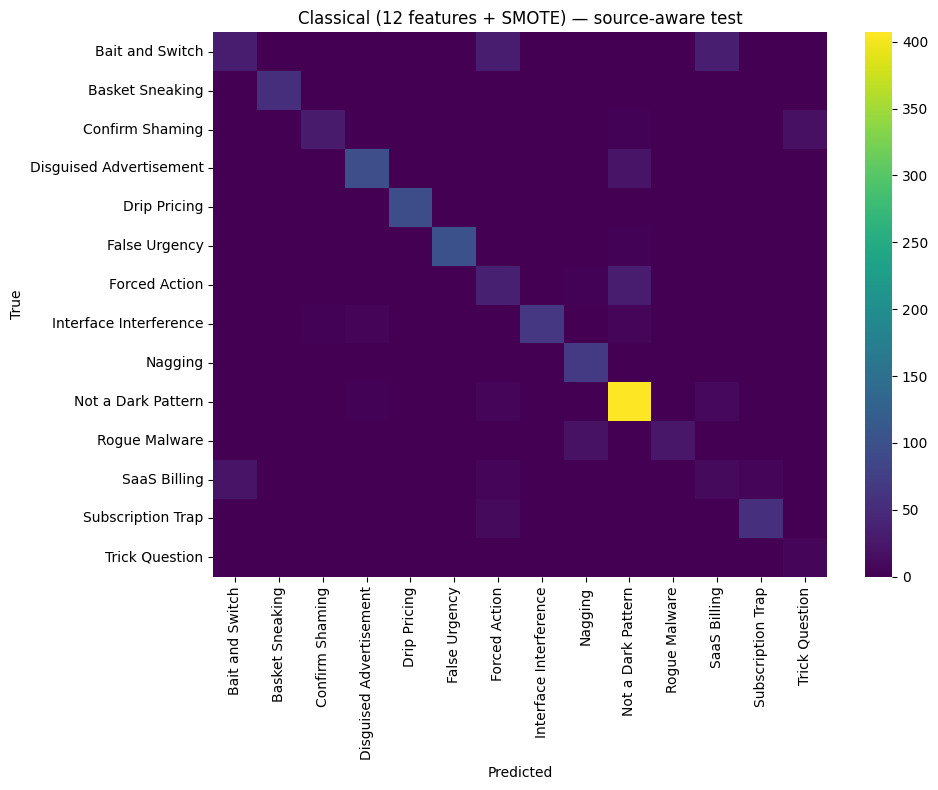

                         precision    recall  f1-score   support

        Bait and Switch       0.59      0.33      0.42        97
        Basket Sneaking       0.98      1.00      0.99        54
        Confirm Shaming       0.91      0.61      0.73        49
Disguised Advertisement       0.93      0.80      0.86       120
           Drip Pricing       1.00      1.00      1.00        95
          False Urgency       0.98      0.96      0.97       105
          Forced Action       0.40      0.51      0.45        70
 Interface Interference       1.00      0.81      0.90        79
                Nagging       0.76      1.00      0.87        68
     Not a Dark Pattern       0.86      0.96      0.91       426
          Rogue Malware       0.96      0.58      0.72        43
           SaaS Billing       0.19      0.24      0.21        42
      Subscription Trap       0.90      0.84      0.87        67
         Trick Question       0.21      0.71      0.32         7

               accuracy

In [15]:
cm = confusion_matrix(y_test, classical_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap='viridis', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title(f'{CLASSICAL_NAME} — source-aware test')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.tight_layout(); plt.show()

print(classification_report(y_test, classical_pred, target_names=CLASSES, zero_division=0))

## 11. Saving the DistilBERT Artifact (run after fine-tuning)

When `RUN_BERT=True` has produced a trained model, this saves an **inference** artifact (the
model + tokenizer + label map), not the training scaffolding — that's what the Streamlit app
will load. Gated the same way so a plain execute doesn't error.

In [16]:
if 'bert' in globals():
    import os
    out = ROOT / 'models/distilbert_darkpattern'
    os.makedirs(out, exist_ok=True)
    globals()['bert'].save_pretrained(out)
    globals()['tok'].save_pretrained(out)
    with open(os.path.join(out, 'label_map.json'), 'w') as f:
        json.dump({'classes': CLASSES, 'max_length': 64}, f, indent=2)
    print('saved DistilBERT inference artifact ->', out)
else:
    print("nothing to save yet — train DistilBERT (cell 7) first.")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.14it/s]

saved DistilBERT inference artifact -> /Users/abhigoyal/Documents/Acadss/Data Science/Projects/dark-pattern-final/models/distilbert_darkpattern
